Looping through images

In [2]:
import numpy as np
from PIL import Image, ImageEnhance, ImageFilter
from scipy.ndimage import convolve

def gaussian_noise(image, mean=0, sigma=15):
    np_image = np.array(image).astype(np.float32)

    noise = np.random.normal(mean, sigma, np_image.shape)

    noise_arr = np.clip(np_image + noise, 0, 255).astype(np.uint8)

    return Image.fromarray(noise_arr)

def motion_blur(image, kernel_size=15):
    np_image = np.array(image)

    kernel = np.zeros((kernel_size, kernel_size))
    kernel[int((kernel_size-1)/2), :] = np.ones(kernel_size)
    kernel /= kernel_size

    blurred = []
    for i in range(np_image.shape[2]):
        blur_chan = convolve(np_image[:, :, i], kernel)
        blurred.append(blur_chan)

    blurred_arr = np.stack(blurred, axis=2).astype(np.uint8)

    return Image.fromarray(blurred_arr)

def defocus_blur(img, radius=3):
    return img.filter(ImageFilter.GaussianBlur(radius=radius))

def jitter(img, brightness=1.0, contrast=1.0):
    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(brightness)

    enhancer = ImageEnhance.Contrast(img)
    img = enhancer.enhance(contrast)

    return img
    
def rayleigh(img, intensity=0.0):
    img = jitter(img, contrast=0.8)
    
    haze_layer = Image.new(mode="RGB", size=img.size, color=(150, 180, 220))

    new_image = Image.blend(img, haze_layer, alpha=intensity)

    return new_image

def sun_glare(img, max_glare=150):
    glaze_layer = Image.new(mode="RGB", size=img.size, color=(255, 245, 235))

    grayscale_mask = np.linspace(max_glare, 0, 64)
    grayscale_mask = np.tile(grayscale_mask, (64, 1))
    grayscale_mask = grayscale_mask.astype(np.uint8)

    mask = Image.fromarray(grayscale_mask, mode="L")
    mask = mask.resize(img.size, Image.Resampling.BICUBIC)

    new_image = Image.composite(glaze_layer, img, mask)

    return new_image

def clouds(img, thickness=1.0, coverage=1.0):
    white_layer = Image.new(mode="RGB", size=img.size, color=(255, 255, 255))

    cloud_mask = np.random.randint(0, 255, size=(4, 4), dtype=np.uint8)
    cloud_mask = Image.fromarray(cloud_mask, mode="L")
    cloud_mask = cloud_mask.resize(img.size, Image.Resampling.BICUBIC)

    b_enhancer = ImageEnhance.Brightness(cloud_mask)
    cloud_mask = b_enhancer.enhance(coverage) 

    c_enhancer = ImageEnhance.Contrast(cloud_mask)
    cloud_mask = c_enhancer.enhance(thickness)

    new_image = Image.composite(white_layer, img, cloud_mask)

    return new_image



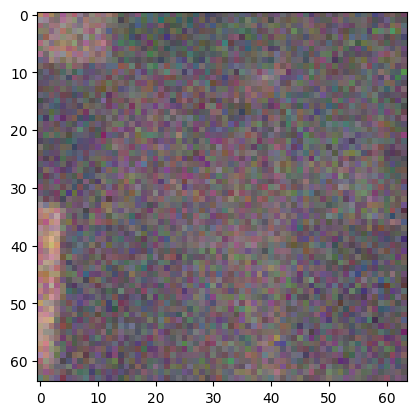

In [12]:
import os
from os import listdir
from PIL import Image
import matplotlib.pyplot as plt

p = "/workspaces/spacecraft-neuromorphic-architecture/src/data/test_images_distorted"
ok = 0

for image_class in os.listdir(p):
    if ok == 1:
        break

    class_path = os.path.join(p, image_class)

    if not os.path.isdir(class_path):
        continue

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)

        try:
            with Image.open(image_path) as img:
                original = img.convert("RGB")

                noise_img = gaussian_noise(original, sigma=15)
                blurred_img = motion_blur(original, kernel_size=4)
                defocused_img = defocus_blur(original, radius=1.5)
                jittered_img = jitter(original, brightness=0.6, contrast=1.2)

                rayleigh_img = rayleigh(original, intensity=0.2)
                sun_glare_img = sun_glare(original, max_glare=150)
                clouds_img = clouds(original, thickness=0.5, coverage=1.5)

                plt.imshow(noise_img)
                plt.axis('on')
                plt.show()
                
                ok = 1
                break
        except Exception as e:
            print(f"Could not process {image_name}: {e}")


In [13]:
import random
import os

events = {
    'atm' : ['clear', 'rayleigh', 'clouds'],
    'light' : ['none', 'sun_glare', 'jitter'],
}

weights = {
    'atm' : [30, 40, 30],
    'light' : [30, 40, 30],
}

p = "/workspaces/spacecraft-neuromorphic-architecture/src/data/test_images_distorted"

for image_class in os.listdir(p):
    class_path = os.path.join(p, image_class)

    if not os.path.isdir(class_path):
            continue

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)

        try:
            with Image.open(image_path) as img:
                chosen_atm = random.choices(events['atm'], weights['atm'])[0]

                if chosen_atm == 'rayleigh':
                    img = rayleigh(img, intensity=random.uniform(0.1, 0.3))
                elif chosen_atm == 'clouds':
                    img = clouds(img, thickness=random.uniform(0.1, 1.5), coverage=random.uniform(0.1, 1.5))

                chosen_light = random.choices(events['light'], weights['light'])[0]

                if chosen_light == 'sun_glare' and chosen_atm != 'clouds':
                     img = sun_glare(img, max_glare=random.randint(100, 150))
                elif chosen_light == 'jitter':
                     img = jitter(img, brightness=random.uniform(0.5, 1.5), contrast=random.uniform(0.6, 1.2))
                      
                if random.random() < 0.15:
                     img = gaussian_noise(img, sigma=random.randint(5, 15))

                if random.random() < 0.10:
                     img = motion_blur(img, kernel_size=random.randint(3, 7))

                if random.random() < 0.10:
                     img = defocus_blur(img, radius=random.uniform(1.0, 2.0))

                img.save(image_path)
                      

        except Exception as e:
            print(f"Could not process {image_name}: {e}")


